# 公式 o1 — Simple Equilibrium（可逆結合 A + B ⇌ A·B）

> **出典（E-Cell4 公式）**: Examples → *Simple Equilibrium* — https://ecell4.e-cell.org/examples/example10.html
>
> これは E-Cell4 **公式ドキュメントの例題**の移植です（bio-d の自作ノートとは別トラック）。公式コードの構造をそのまま使い、
> インストール版（ecell4 1.2.2）で走るよう最小限だけ調整しています（下記「公式からの変更点」参照）。

**この例が教えること**: `run_simulation` の高レベル API ではなく、**低レベルの World / Simulator / Factory** を直接使う書き方。
反応は `create_binding_reaction_rule` / `create_unbinding_reaction_rule` の**ファクトリ関数**で作る。系は結合平衡 $A+B \rightleftharpoons A\cdot B$。

**公式からの変更点**: 公式は単分子解像度の `egfrd.Factory()` を使う（本環境では ~70 秒と重い）。ここでは同じ低レベル手順のまま
`gillespie.Factory()` に差し替えて高速化した。**1 行 `f = egfrd.Factory()` に戻せば公式どおりの単分子版**になる。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

# シミュレーション法（公式は egfrd.Factory()。速度のため gillespie に差し替え）
f = gillespie.Factory()

# パラメータ（公式のまま）
L, N, kd, U, D, radius = 1.0, 60, 0.1, 0.5, 1.0, 0.01
volume = L * L * L
ka = kd * volume * (1 - U) / (U * U * N)

sp1, sp2, sp3 = Species('A', radius, D), Species('B', radius, D), Species('A_B', radius, D)
m = NetworkModel()
for sp in (sp1, sp2, sp3): m.add_species_attribute(sp)
m.add_reaction_rule(create_binding_reaction_rule(sp1, sp2, sp3, ka))    # A + B -> A_B
m.add_reaction_rule(create_unbinding_reaction_rule(sp3, sp1, sp2, kd))  # A_B -> A + B

w = f.world(Real3(L, L, L)); w.bind_to(m)
w.add_molecules(Species('A'), N); w.add_molecules(Species('B'), N)
sim = f.simulator(w)

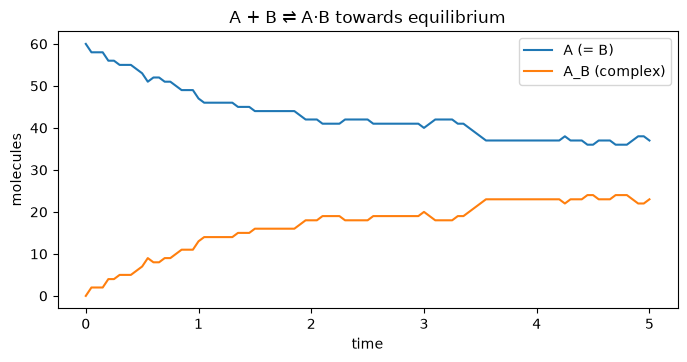

equilibrium: A=37, A_B=23 (of N=60)


In [2]:
# 公式どおり: World/Simulator を手でステップして分子数を記録
next_time, dt = 0.0, 0.05
data = [(w.t(), w.num_molecules(sp1), w.num_molecules(sp3))]
for i in range(100):
    next_time += dt
    while sim.step(next_time): pass
    data.append((w.t(), w.num_molecules(sp1), w.num_molecules(sp3)))
t = [d[0] for d in data]
plt.figure(figsize=(8,3.6))
plt.plot(t, [d[1] for d in data], label='A (= B)')
plt.plot(t, [d[2] for d in data], label='A_B (complex)')
plt.xlabel('time'); plt.ylabel('molecules'); plt.legend(); plt.title('A + B ⇌ A·B towards equilibrium'); plt.show()
print('equilibrium: A=%d, A_B=%d (of N=%d)' % (data[-1][1], data[-1][2], N))

## 読み取り

遊離 A（=B）と複合体 A·B が結合/解離を繰り返し、$k_a/k_d$ と体積で決まる**結合平衡**に落ち着く。パラメータ `ka` は
「平衡で複合体率が $U=0.5$ になるよう」逆算されている（公式の式）。

**このノートの要点（公式が教えたい API）**:
- `run_simulation(...)` を使わず、`Factory → world → simulator → step` の**低レベル手順**を直接踏む。
- 反応は DSL でなく `create_binding_reaction_rule` / `create_unbinding_reaction_rule` の**ファクトリ関数**で構築。
- **ソルバは Factory を差し替えるだけ**で切り替わる（`gillespie` / `ode` / `meso` / `spatiocyte` / `egfrd` / `bd`）。
  1 行を `f = egfrd.Factory()` にすれば、まさに公式どおりの単分子（粒子）シミュレーションになる。